# 图像增广

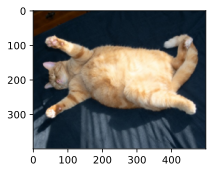

In [26]:
# 作用是告诉Matplotlib：把画出来的图直接嵌入到notebook单元格的输出里，而不是弹出一个独立窗口。
%matplotlib inline

# 导包
import torch
import torchvision
from torch import nn
from d2l import torch as d2l

d2l.set_figsize()       # 统一设置 Matplotlib 图形的默认尺寸
img = d2l.Image.open('./img/cat1.jpg')
d2l.plt.imshow(img)

In [27]:
# 定义函数，用于：对图像进行增广，并显示增广后的图像
# 参1：图像；参2：增广器（其实就是一个定义了数据增广手段的函数）；参3：行数；参4：列数；参5：缩放比例
def apply(img, aug, num_rows = 2, num_cols = 4, scale = 1.5):
    Y = [aug(img) for _ in range(num_cols * num_rows)]
    d2l.show_images(Y, num_rows, num_cols, scale = scale)

## 左右翻转图像

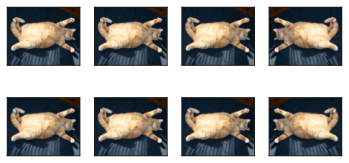

In [28]:
apply(img, torchvision.transforms.RandomHorizontalFlip())

## 上下翻转图像

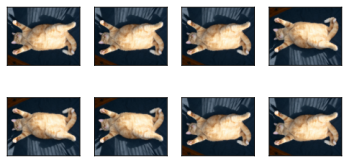

In [29]:
apply(img, torchvision.transforms.RandomVerticalFlip())

## 随机裁剪

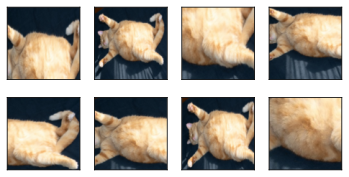

In [30]:
# 定义随机裁剪增广器
# 参1：裁剪后的输出图像大小；参2：裁剪面积比例范围（从10%到100%随机取）；参3：宽高比（在0.5到2.0之间随机取）
shape_aug = torchvision.transforms.RandomResizedCrop((200, 200), scale = (0.1, 1), ratio = (0.5, 2))
apply(img, shape_aug)

## 随机更改图像亮度

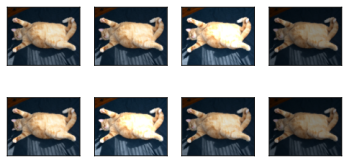

In [31]:
# ColorJitter：颜色变换增强类
# 参1：亮度（0.5表示在[1-0.5, 1+0.5] = [0.5, 1.5]倍之间随机变换）；参2：对比度（0表示不变）；参3：饱和度（0即不变）；参4：色相（0即不变）
apply(img, torchvision.transforms.ColorJitter(brightness = 0.5, contrast = 0, saturation = 0, hue = 0))

## 随机改变图像色调

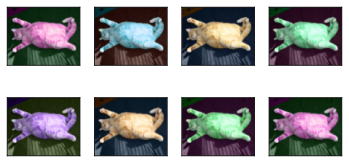

In [32]:
# ColorJitter：颜色变换增强类
# 参1：亮度（0表示不变）；参2：对比度（0即不变）；参3：饱和度（0即不变）；参4：色相（0.5表示在[1-0.5, 1+0.5] = [0.5, 1.5]倍之间随机变换）
apply(img, torchvision.transforms.ColorJitter(brightness = 0, contrast = 0, saturation = 0, hue = 0.5))

## 随机改变图像亮度（`brightness`）、对比度（`contrast`）、饱和度（`saturation`）和色调（`due`）

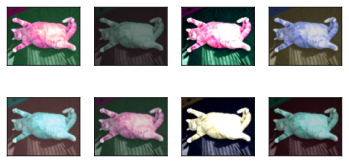

In [33]:
# 0.5表示在[1-0.5, 1+0.5] = [0.5, 1.5]倍之间随机变换
color_aug = torchvision.transforms.ColorJitter(brightness = 0.5, contrast = 0.5, saturation = 0.5, hue = 0.5)
apply(img, color_aug)

## 结合多种图像增广方法

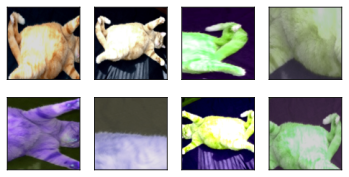

In [34]:
# 通过Compose将多种增广方法结合起来，从而apply依次自动执行列表里的三个变换
# Compose：把多个图像变换操作串联成一个整体，相当于一条流水线
augs = torchvision.transforms.Compose([torchvision.transforms.RandomHorizontalFlip(),color_aug, shape_aug])
apply(img, augs)

## 使用图像增广进行训练

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >], dtype=object)

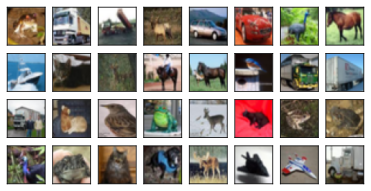

In [35]:
all_images = torchvision.datasets.CIFAR10(
    train = True, root = '../../pytorch/Day34/data', download =False)
# 参1：图片列表；参2：网格的行数；参3：网格的列数；参4：显示比例
d2l.show_images([all_images[i][0] for i in range(32)], 4, 8, scale = 0.8)

## 只使用最简单的随机左右翻转

In [50]:
# 数据增广一般只在训练时候做，测试时候一般不做
train_augs = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(),      # 训练时使用随机左右翻转
    torchvision.transforms.ToTensor()])                 # 把结果变成4维矩阵，以便可以训练

test_augs = torchvision.transforms.Compose([            # 测试时不做图像增广
    torchvision.transforms.ToTensor()])                 # 把结果变成4维矩阵，以便可以训练

## 定义一个辅助函数，以便于读取图像和应用图像增广

In [51]:
def load_cifar10(is_train, augs, batch_size):
    # 参1：数据集路径；参2：是否训练状态；参3：数据增广手段；参4：是否下载
    dataset = torchvision.datasets.CIFAR10(              # transform = augs：加载数据集时直接做数据增广
        root = '../../pytorch/Day34/data', train = is_train, transform = augs, download = False)
    # 参1：数据集；参2：批次大小；参2：是否打乱；参4：用多少个子进程来并行加载数据（通常来说如果做了图像增广，这个参数应该设置大一点）
    dataloader = torch.utils.data.DataLoader(
        dataset, batch_size = batch_size, shuffle = is_train, num_workers = 4)
    return dataloader

## 定义一个函数，使用多GPU对模型进行训练和评估

In [52]:
def train_batch_ch13(net, X, y, loss, trainer, devices):
    if isinstance(X, list):
        X = [x.to(devices[0]) for x in X]
    else:
        X = X.to(devices[0])
    y = y.to(devices[0])
    net.train()             # 切换模型状态到训练
    y_pred = net(X)         # 模型预测
    l = loss(y_pred, y)     # 损失计算
    trainer.zero_grad()     # 梯度清零
    l.sum().backward()      # 反向传播
    trainer.step()          # 梯度更新
    train_loss_sum = l.sum()
    train_acc_sum = d2l.accuracy(y_pred, y)
    return train_loss_sum, train_acc_sum

def train_ch13(net, train_iter, test_iter, loss, trainer, num_epochs, devices = d2l.try_all_gpus()):
    timer, num_batches = d2l.Timer(), len(train_iter)
    animator = d2l.Animator(xlabel = 'epoch', xlim = [1, num_epochs], ylim = [0, 1], legend = ['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        metric = d2l.Accumulator(4)
        for i, [features, labels] in enumerate(train_iter):
            timer.start()
            l ,acc = train_batch_ch13(net, features, labels, loss, trainer, devices)
            metric.add(l, acc, labels.shape[0], labels.numel())
            timer.stop()
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches, (metric[0]/ metric[2], metric[1]/ metric[3], None))
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {metric[0] / metric[2]:.3f}, train acc '
          f'{metric[1] / metric[3]:.3f}, test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec on '
          f'{str(devices)}')

## 定义`train_with_data_aug`函数，使用图像增广来训练模型

In [53]:
batch_size, devices, net = 256, d2l.try_all_gpus(), d2l.resnet18(10, 3)         # d2l.resnet18(10, 3)参1：分类数；参2：输入通道数

def init_weights(m):
    if type(m) in [nn.Linear, nn.Conv2d]:
        nn.init.xavier_uniform_(m.weight)

net.apply(init_weights)

def train_with_data_aug(train_augs, test_augs, net, lr = 0.001):
    net.to(devices[0])
    train_iter = load_cifar10(True, train_augs, batch_size)
    test_iter = load_cifar10(False, test_augs, batch_size)
    loss = nn.CrossEntropyLoss(reduction = "none")      # reduction="none"：不做任何汇总，原样返回每个样本的loss。
    trainer = torch.optim.Adam(net.parameters(), lr = lr)
    train_ch13(net, train_iter, test_iter, loss, trainer, 10, devices)

## 训练模型

loss 0.200, train acc 0.930, test acc 0.851
1807.7 examples/sec on [device(type='cuda', index=0)]


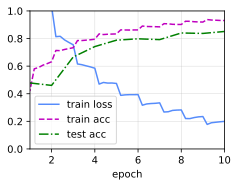

In [54]:
train_with_data_aug(train_augs, test_augs, net)

## 不使用增广训练模型

loss 0.039, train acc 0.986, test acc 0.866
1793.8 examples/sec on [device(type='cuda', index=0)]


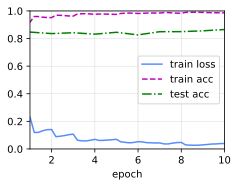

In [49]:
train_augs = test_augs
train_with_data_aug(train_augs, test_augs, net)